In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

In [3]:
from option import CallOption, PutOption
from underlying import GeometricBrownianMotion

In [4]:
start = 5
end = 200
n_pts = ((end - start) // start) + 1
x_axis = np.linspace(start, end, n_pts)

In [5]:
spot = 100 # $100
rate = 0.05 # 5%
drift = 0.3 # 30%
sigma = 0.2 # 20%

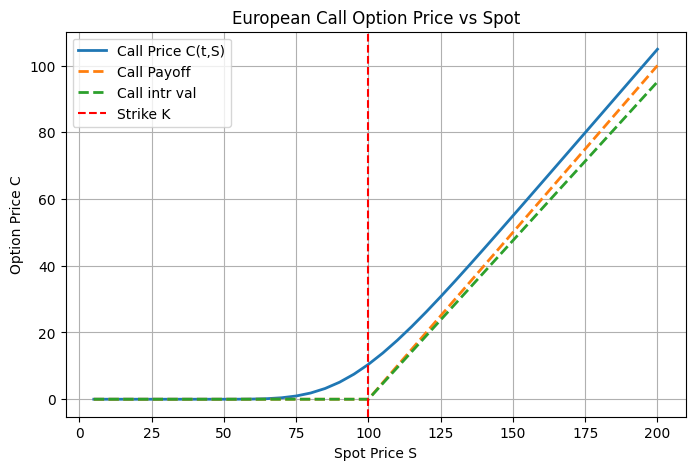

In [6]:
strike = 100
call = CallOption(strike,1)

plt.figure(figsize=(8,5))
plt.plot(x_axis, call.price(x_axis, 0, rate, sigma), label='Call Price C(t,S)', linewidth=2)
plt.plot(x_axis, call.payoff(x_axis), '--', label='Call Payoff', linewidth=2)
plt.plot(x_axis, call.discounted_payoff(x_axis, 0, rate), '--', label='Call intr val', linewidth=2)
plt.axvline(strike, color='red', linestyle='--', label='Strike K')
plt.xlabel('Spot Price S')
plt.ylabel('Option Price C')
plt.title('European Call Option Price vs Spot')
plt.legend()
plt.grid(True)

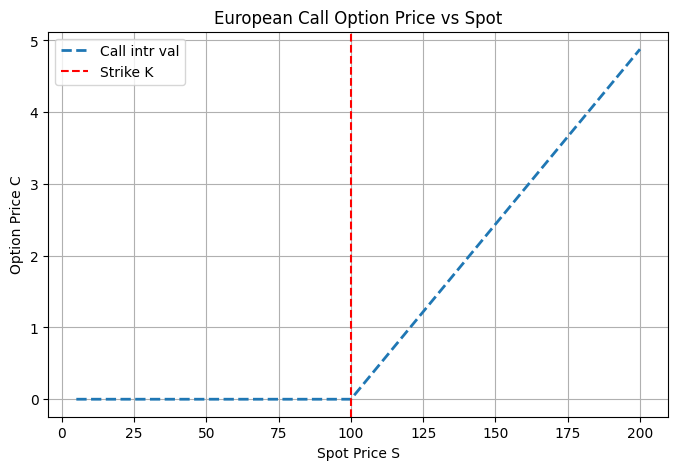

In [7]:
plt.figure(figsize=(8,5))
plt.plot(x_axis, call.payoff(x_axis) - call.discounted_payoff(x_axis, 0, rate), '--', label='Call intr val', linewidth=2)
plt.axvline(strike, color='red', linestyle='--', label='Strike K')
plt.xlabel('Spot Price S')
plt.ylabel('Option Price C')
plt.title('European Call Option Price vs Spot')
plt.legend()
plt.grid(True)

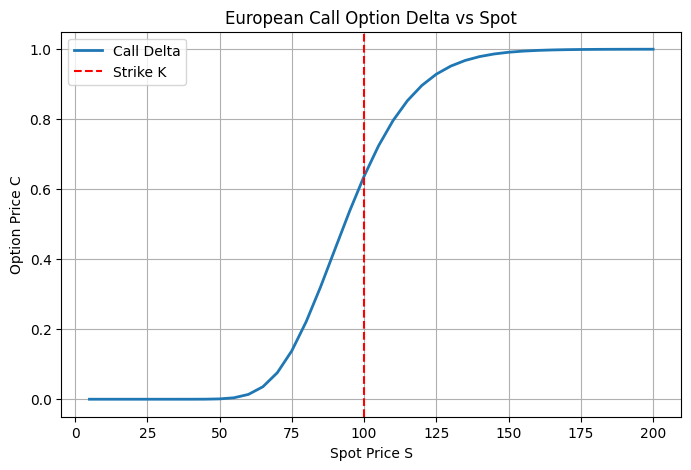

In [8]:
plt.figure(figsize=(8,5))
plt.plot(x_axis, call.delta(x_axis, 0, rate, sigma), label='Call Delta', linewidth=2)
plt.axvline(strike, color='red', linestyle='--', label='Strike K')
plt.xlabel('Spot Price S')
plt.ylabel('Option Price C')
plt.title('European Call Option Delta vs Spot')
plt.legend()
plt.grid(True)

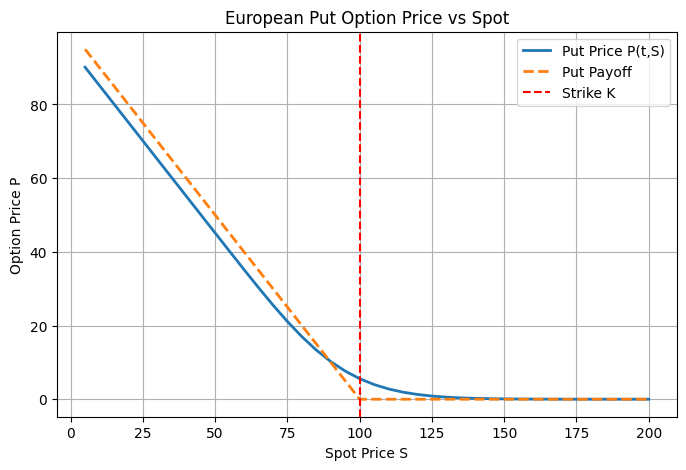

In [9]:
put = PutOption(100,1)

plt.figure(figsize=(8,5))
plt.plot(x_axis, put.price(x_axis, 0, rate, sigma), label='Put Price P(t,S)', linewidth=2)
plt.plot(x_axis, put.payoff(x_axis), '--', label='Put Payoff', linewidth=2)
plt.axvline(strike, color='red', linestyle='--', label='Strike K')
plt.xlabel('Spot Price S')
plt.ylabel('Option Price P')
plt.title('European Put Option Price vs Spot')
plt.legend()
plt.grid(True)

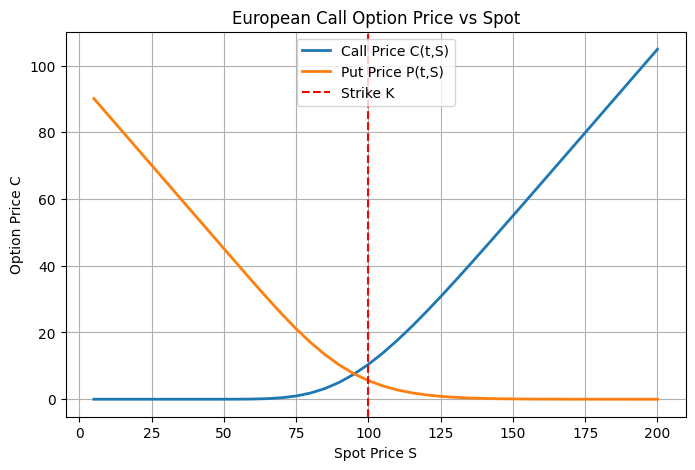

In [10]:
call = CallOption(strike,1)
put = PutOption(100,1)


plt.figure(figsize=(8,5))
plt.plot(x_axis, call.price(x_axis, 0, rate, sigma), label='Call Price C(t,S)', linewidth=2)
plt.plot(x_axis, put.price(x_axis, 0, rate, sigma), label='Put Price P(t,S)', linewidth=2)
plt.axvline(strike, color='red', linestyle='--', label='Strike K')
plt.xlabel('Spot Price S')
plt.ylabel('Option Price C')
plt.title('European Call Option Price vs Spot')
plt.legend()
plt.grid(True)

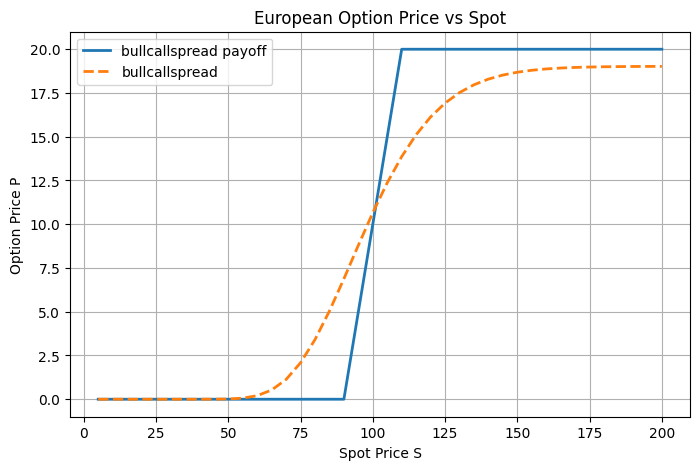

In [11]:
bullcallspread = CallOption(90,1) - CallOption(110,1)

plt.figure(figsize=(8,5))
plt.plot(x_axis, bullcallspread.payoff(x_axis), label='bullcallspread payoff', linewidth=2)
plt.plot(x_axis, bullcallspread.price(x_axis, 0, rate, sigma), '--', label='bullcallspread', linewidth=2)
plt.xlabel('Spot Price S')
plt.ylabel('Option Price P')
plt.title('European Option Price vs Spot')
plt.legend()
plt.grid(True)

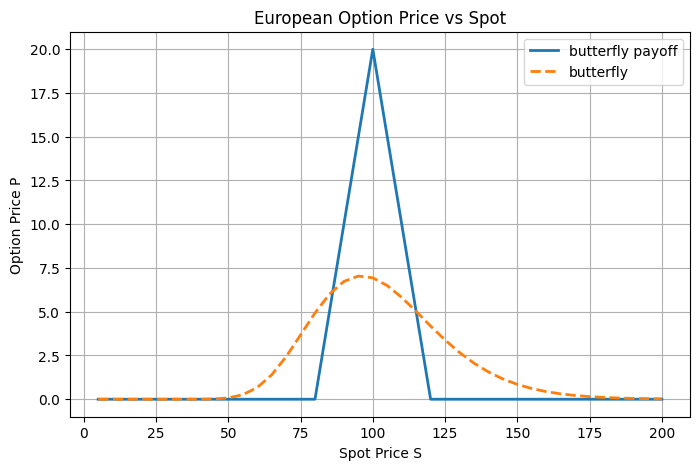

In [12]:
butterfly = CallOption(80, 1) - 2*CallOption(100, 1) + CallOption(120, 1)

plt.figure(figsize=(8,5))
plt.plot(x_axis, butterfly.payoff(x_axis), label='butterfly payoff', linewidth=2)
plt.plot(x_axis, butterfly.price(x_axis, 0, rate, sigma), '--', label='butterfly', linewidth=2)
plt.xlabel('Spot Price S')
plt.ylabel('Option Price P')
plt.title('European Option Price vs Spot')
plt.legend()
plt.grid(True)

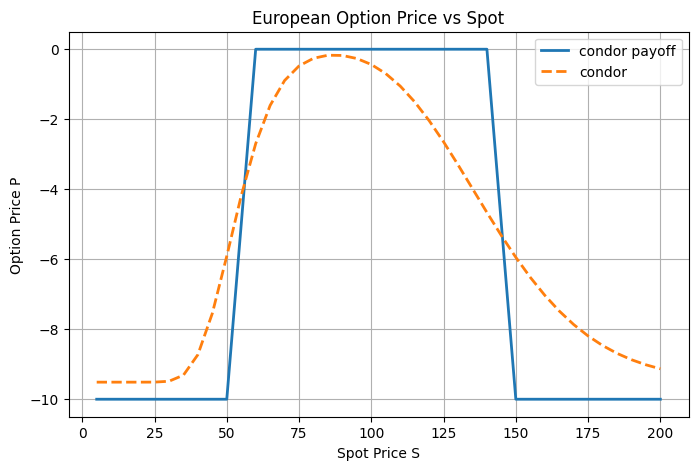

In [13]:
condor = PutOption(50,1) - PutOption(60,1) - CallOption(140,1) + CallOption(150,1)

plt.figure(figsize=(8,5))
plt.plot(x_axis, condor.payoff(x_axis), label='condor payoff', linewidth=2)
plt.plot(x_axis, condor.price(x_axis, 0, rate, sigma), '--', label='condor', linewidth=2)
plt.xlabel('Spot Price S')
plt.ylabel('Option Price P')
plt.title('European Option Price vs Spot')
plt.legend()
plt.grid(True)

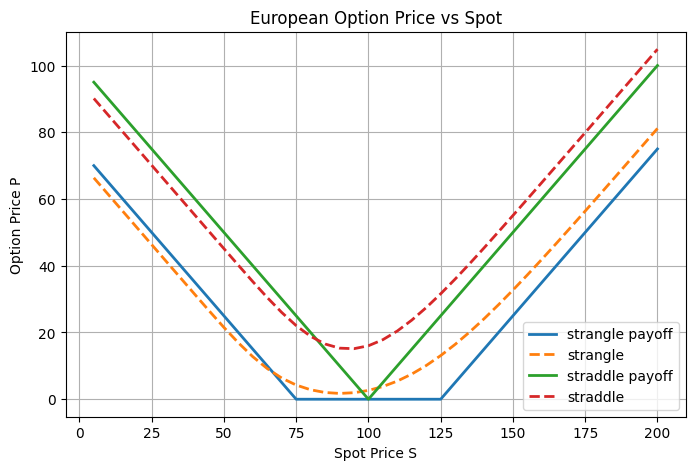

In [14]:
strangle = CallOption(125,1) + PutOption(75,1)
straddle = CallOption(100,1) + PutOption(100,1)

plt.figure(figsize=(8,5))
plt.plot(x_axis, strangle.payoff(x_axis), label='strangle payoff', linewidth=2)
plt.plot(x_axis, strangle.price(x_axis, 0, rate, sigma), '--', label='strangle', linewidth=2)
plt.plot(x_axis, straddle.payoff(x_axis), label='straddle payoff', linewidth=2)
plt.plot(x_axis, straddle.price(x_axis, 0, rate, sigma), '--', label='straddle', linewidth=2)
plt.xlabel('Spot Price S')
plt.ylabel('Option Price P')
plt.title('European Option Price vs Spot')
plt.legend()
plt.grid(True)

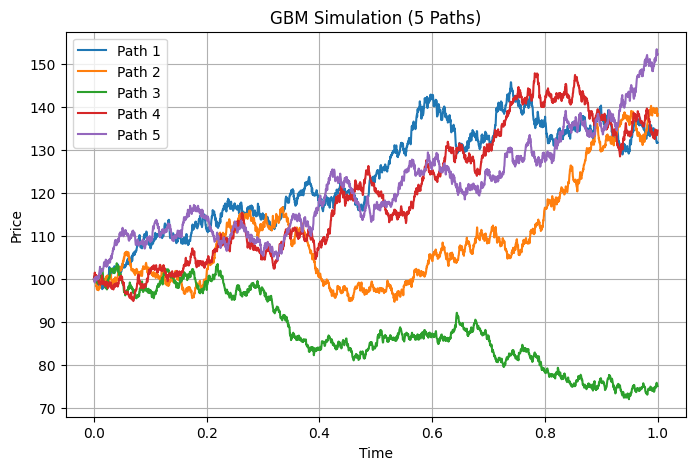

In [15]:
spot = 100
drift = 0.08
maturity = 1
sigma = 0.2
mesh = 1/252
runs = 5

underlying = GeometricBrownianMotion(spot, drift, sigma, maturity, runs, mesh, 10)

time_grid = np.linspace(0, maturity, underlying.length+1)
plt.figure(figsize=(8,5))
for i in range(runs):
    plt.plot(time_grid, underlying.paths[i], label=f'Path {i+1}')

plt.title(f'GBM Simulation ({runs} Paths)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)